In [2]:
import rasterio
import numpy as np
import geopandas as gpd
import pandas as pd
from rasterstats import zonal_stats
import seaborn as sns
import matplotlib.pyplot as plt
from rasterio.warp import calculate_default_transform, reproject, Resampling
from rasterstats import point_query
from rasterio.features import geometry_mask



In [3]:
dst_file = r"C:\Users\bsf31\Documents\data\NM\USDA\short_park_cht.tif"


In [4]:
# Open the raster file
with rasterio.open(dst_file) as src:
    canopy_data = src.read(1)  # Read the first band
    pixel_area = src.res[0] * src.res[1]  # Area of each pixel in square meters

In [5]:
pixel_area

0.08999999999999002

In [6]:
with rasterio.open(dst_file) as src:
    print("Resolution:", src.res)

Resolution: (0.29999999999996674, 0.3)


## Overstory Statistics (Height > 2 meters) Entire Extent

In [7]:
# Conversion factor
meters_to_feet = 3.28084
square_meters_to_square_feet = 10.7639

In [8]:
canopy_threshold = 2  # Minimum height in meters for a pixel to be considered canopy

In [9]:
# Mask canopy pixels above threshold
canopy_mask = canopy_data > canopy_threshold

In [10]:
# Calculate the total area of canopy cover
canopy_area = np.sum(canopy_mask) * pixel_area  # Area in square meters
canopy_area_hectares = canopy_area / 10000  # Convert to hectares

In [11]:
canopy_area_sqft = canopy_area * square_meters_to_square_feet  # Convert to square feet


In [12]:
canopy_heights = canopy_data[canopy_mask]  # Extract heights where canopy exists

In [13]:
# Convert height statistics to feet
mean_height_ft = np.mean(canopy_heights) * meters_to_feet
median_height_ft = np.median(canopy_heights) * meters_to_feet
min_height_ft = np.min(canopy_heights) * meters_to_feet
max_height_ft = np.max(canopy_heights) * meters_to_feet
std_dev_height_ft= np.std(canopy_heights) * meters_to_feet

In [14]:
print(f"Total Canopy Area: {canopy_area_sqft:.2f} square feet")
print("Canopy Height Statistics:")
print(f"Mean Height: {mean_height_ft:.2f} feet")
print(f"Median Height: {median_height_ft:.2f} feet")
print(f"Minimum Height: {min_height_ft:.2f} feet")
print(f"Maximum Height: {max_height_ft:.2f} feet")
print(f"Standard Deviation of Height: {std_dev_height_ft:.2f} feet")

Total Canopy Area: 2250.41 square feet
Canopy Height Statistics:
Mean Height: 13.91 feet
Median Height: 11.54 feet
Minimum Height: 6.56 feet
Maximum Height: 43.42 feet
Standard Deviation of Height: 7.14 feet


# Understory/Overstory Stats by Region

In [15]:
nm_path = r"C:\Users\bsf31\Documents\data\NM\nm_vector.gpkg"
gdf = gpd.read_file(nm_path, layer='short_park')

In [16]:
def canopy_area(arr, mask):
    valid_data = np.isfinite(arr) & (arr > canopy_threshold)
    return np.sum(valid_data) * pixel_area * square_meters_to_square_feet

In [17]:
# Calculate zonal statistics for each polygon in hurley_gdf
stats = zonal_stats(
    gdf,
    dst_file,
    stats=["mean", "median", "min", "max", "std"],
    add_stats={'area': canopy_area},
    prefix="canopy_"
)
zonal_df = pd.DataFrame(stats)
gdf = gdf.join(zonal_df)



In [18]:
stats

[{'canopy_min': 0.010020114481449127,
  'canopy_max': 13.234051704406738,
  'canopy_mean': 0.030325177895107934,
  'canopy_std': 0.2573269773794187,
  'canopy_median': 0.01023857668042183,
  'canopy_area': np.float64(2250.40857299975)}]

In [19]:
33.01156826
20.14881285
15.51635442
19.78896314
12.86281628
39.93774207
32.2919435
24.96102666
47.94322494
12.90775567
70.87925115
25.59030594
32.02155319
33.77558401
33.32592818
49.65143281
29.36810156
26.12999502
65.12260052
11.10859184
41.51180739
34.54069753
26.8500372
22.03772028
20.95834364
34.76558177
28.06436386
13.40252457
66.24792795
49.51730713
48.57287072
76.00756145
45.19969698
34.22586109
16.10099851
30.85280087
15.156522
22.17257634
15.65124613
14.84168229
45.55977235
90.44437949
45.73929401
21.54297833
63.95424572
16.73064326
22.98216673
39.8926711
18.61953176
75.01799746
34.72055389
38.8582585
40.29746051
26.89497476
15.51637621
37.41903835
14.21201015
17.76510691
19.56397896
16.5057372
22.12761002
19.38419552
22.93724682
14.84170676
18.97941974
13.80727328
18.57460224
23.79166744
19.92382315
5.486911085
19.02432792
15.29144494
28.60403507
17.67510877
27.97435582
26.89499486
3.569976397
4.426171825
3.212235266
3.849744697
4.109642837
8.887718747
4.101542697
18.28188452
3.576775276
5.246929492
4.589327679
5.722183868
7.681434267
9.591850321
6.262005162
2.364297976
3.725483249
2.899386618
7.389474416
6.844678799
5.498691391
17.6971738
16.27456053
2.171954946
14.63459691
7.147067812
14.92942035
12.03995208
4.951213462



4.951213462

In [20]:
2522.254954



2522.254954

In [21]:
zonal_df

,canopy_min,canopy_max,canopy_mean,canopy_std,canopy_median,canopy_area
0,0.01002,13.234052,0.030325,0.257327,0.010239,2250.408573


In [22]:
gdf['canopy_area'] =2522.254954



In [23]:
gdf

,place,area,geometry,canopy_min,canopy_max,canopy_mean,canopy_std,canopy_median,canopy_area
0,Short Park,78286.309453,"MULTIPOLYGON Z (((714532.864 3581758.736 0, 71...",0.01002,13.234052,0.030325,0.257327,0.010239,2522.254954


In [24]:
# Convert height statistics to feet
gdf['canopy_mean'] *= meters_to_feet
gdf['canopy_median'] *= meters_to_feet
gdf['canopy_min'] *= meters_to_feet
gdf['canopy_max'] *= meters_to_feet
gdf['canopy_std'] *= meters_to_feet
gdf['canopy_area'] *= square_meters_to_square_feet

In [25]:
# Group by 'temp_name' to get aggregated canopy statistics
grouped_stats = gdf.groupby("place").agg({
    'canopy_mean':'mean',
    'canopy_median':'mean',
    'canopy_min': 'min',
    'canopy_max': 'max',
    'canopy_std': 'mean',
    'canopy_area': 'sum'
}).reset_index()

In [26]:
total_canopy_area = grouped_stats['canopy_area'].sum()

In [27]:
print(gdf)

        place          area  \
0  Short Park  78286.309453   

                                            geometry  canopy_min  canopy_max  \
0  MULTIPOLYGON Z (((714532.864 3581758.736 0, 71...    0.032874   43.418806   

   canopy_mean  canopy_std  canopy_median   canopy_area  
0     0.099492    0.844249       0.033591  27149.300099  


In [28]:
gdf.columns

Index(['place', 'area', 'geometry', 'canopy_min', 'canopy_max', 'canopy_mean',
       'canopy_std', 'canopy_median', 'canopy_area'],
      dtype='object')

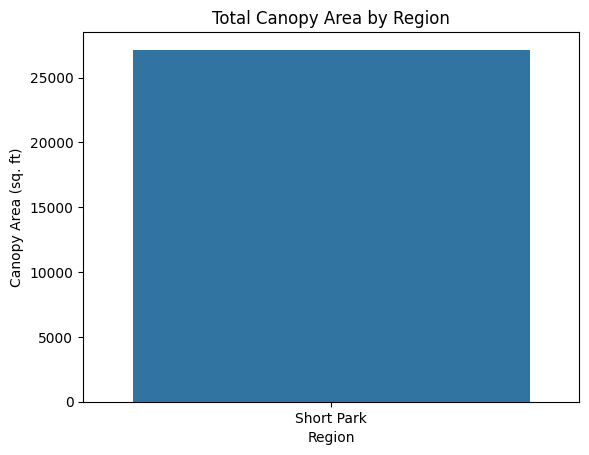

In [29]:
sns.barplot(x='place', y='canopy_area', data=grouped_stats)
plt.title('Total Canopy Area by Region')
plt.xlabel('Region')
plt.ylabel('Canopy Area (sq. ft)')
plt.show()

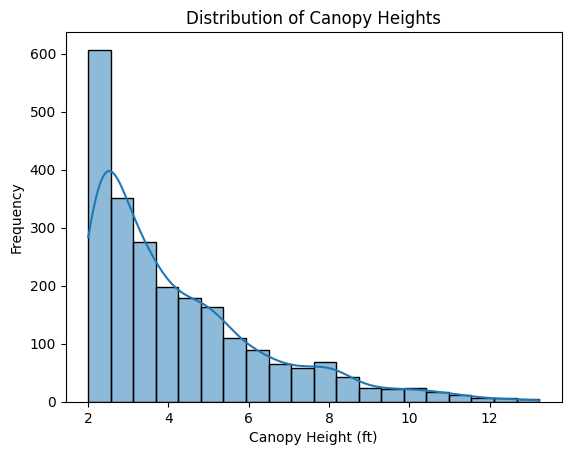

In [30]:
sns.histplot(canopy_heights, bins=20, kde=True)
plt.title('Distribution of Canopy Heights')
plt.xlabel('Canopy Height (ft)')
plt.ylabel('Frequency')
plt.show()


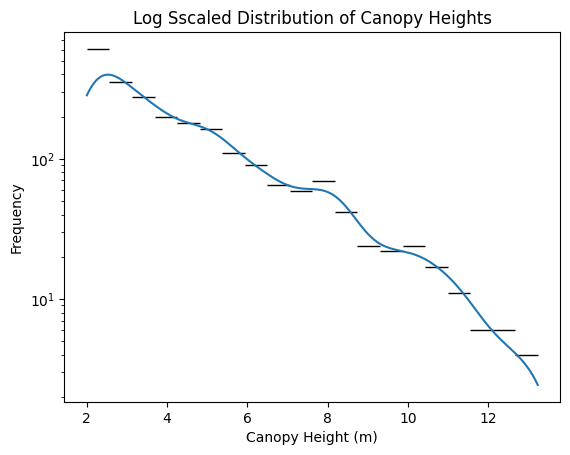

In [31]:
sns.histplot(canopy_heights, bins=20, kde=True, log_scale=(False, True))
plt.title('Log Sscaled Distribution of Canopy Heights')
plt.xlabel('Canopy Height (m)')
plt.ylabel('Frequency')
plt.show()

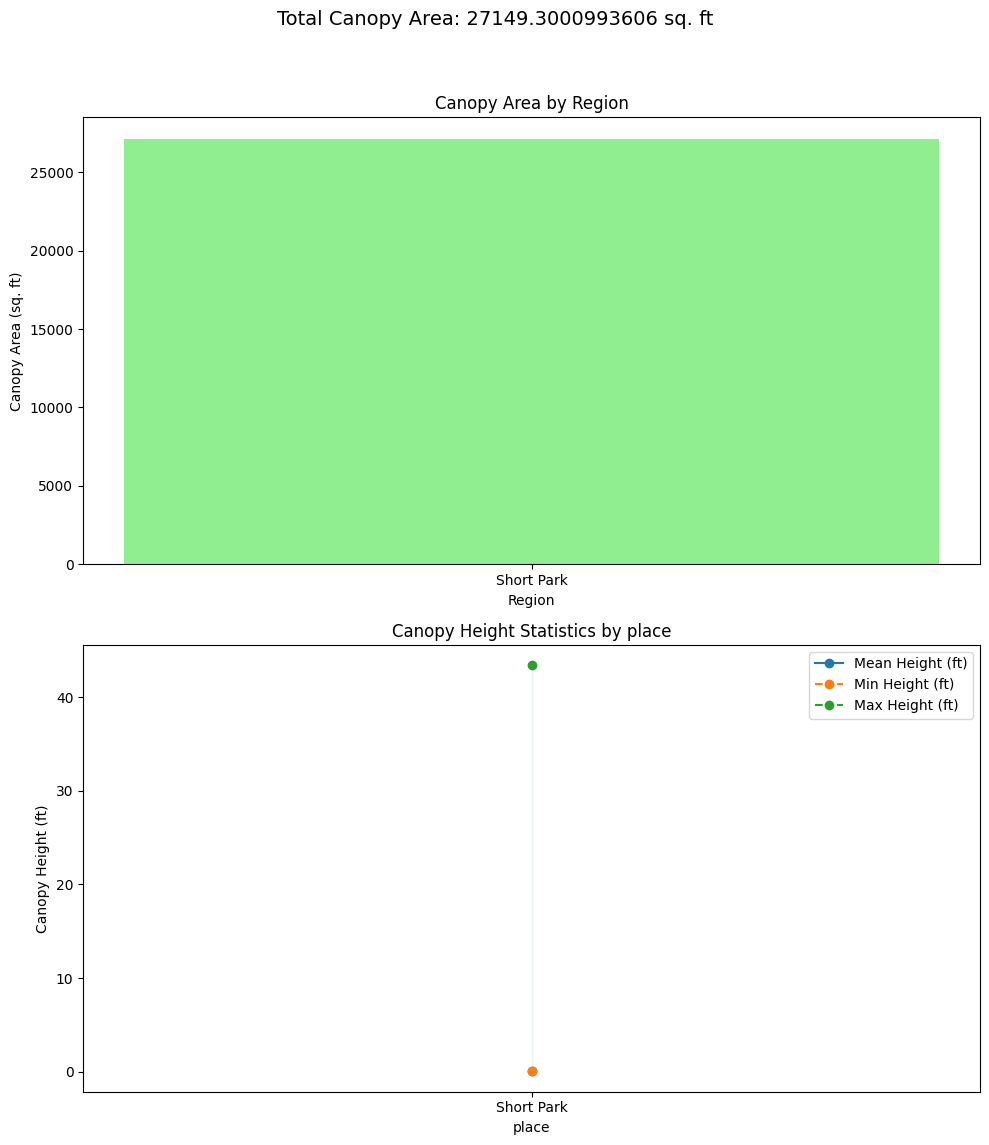

In [32]:
# Plotting
fig, ax = plt.subplots(2, 1, figsize=(10, 12))

# Bar chart for canopy area by place
ax[0].bar(gdf["place"], gdf["canopy_area"], color='lightgreen')
ax[0].set_title("Canopy Area by Region")
ax[0].set_ylabel("Canopy Area (sq. ft)")
ax[0].set_xlabel("Region")
# Line plot for canopy height stats by place
ax[1].plot(gdf["place"], gdf["canopy_mean"], marker='o', label='Mean Height (ft)')
ax[1].plot(gdf["place"], gdf["canopy_min"], marker='o', linestyle='--', label='Min Height (ft)')
ax[1].plot(gdf["place"], gdf["canopy_max"], marker='o', linestyle='--', label='Max Height (ft)')
ax[1].fill_between(gdf["place"], gdf["canopy_min"], gdf["canopy_max"], color='lightblue', alpha=0.3)
ax[1].set_title("Canopy Height Statistics by place")
ax[1].set_ylabel("Canopy Height (ft)")
ax[1].set_xlabel("place")
ax[1].legend()

# Display the total canopy area on the plot
fig.suptitle(f"Total Canopy Area: {total_canopy_area} sq. ft", fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [33]:
# %% Calculate Understory and Overstory Stats for Each Polygon
def calculate_region_understory_overstory_stats(geometry, canopy_raster, mask, transform):
    """Calculate understory and overstory stats for a specific polygon region."""
    # Mask the raster by the geometry
    region_mask = rasterio.features.geometry_mask(
        [geometry], transform=transform, invert=True, out_shape=canopy_raster.shape)
    
    combined_mask = region_mask & mask  # Combine with canopy mask
    
    # Separate understory and overstory
    understory_mask = (canopy_raster > 1) & (canopy_raster <= 3) & combined_mask
    overstory_mask = (canopy_raster > 3) & combined_mask
    
    # Calculate areas
    understory_area = np.sum(understory_mask) * pixel_area
    overstory_area = np.sum(overstory_mask) * pixel_area
    
    # Percentages (relative to the region area)
    region_area = np.sum(region_mask) * pixel_area
    understory_percent = (understory_area / region_area) * 100 if region_area > 0 else 0
    overstory_percent = (overstory_area / region_area) * 100 if region_area > 0 else 0
    
    return {
        'understory_area': understory_area,
        'understory_percent': understory_percent,
        'overstory_area': overstory_area,
        'overstory_percent': overstory_percent
    }

In [34]:
# %% Apply Stats Calculation to Each Region in the GeoDataFrame
with rasterio.open(dst_file) as src:
    canopy_data = src.read(1)
    transform = src.transform

    stats = []
    for _, row in gdf.iterrows():
        stats.append(calculate_region_understory_overstory_stats(
            row.geometry, canopy_data, canopy_mask, transform))

In [35]:

# Convert stats to a DataFrame and merge with GeoDataFrame
stats_df = pd.DataFrame(stats)


In [36]:
stats_df

,understory_area,understory_percent,overstory_area,overstory_percent
0,80.01,0.102167,129.06,0.1648


In [37]:
gdf = pd.concat([gdf, stats_df], axis=1)
gdf

,place,area,geometry,canopy_min,canopy_max,canopy_mean,canopy_std,canopy_median,canopy_area,understory_area,understory_percent,overstory_area,overstory_percent
0,Short Park,78286.309453,"MULTIPOLYGON Z (((714532.864 3581758.736 0, 71...",0.032874,43.418806,0.099492,0.844249,0.033591,27149.300099,80.01,0.102167,129.06,0.1648


In [38]:
# %% Recalculate Canopy Cover Percent
gdf['canopy_cover_percent'] = (
    (gdf['understory_area'] + gdf['overstory_area']) / gdf['area']) * 100

# %% Group by Region and Summarize
summary_stats = gdf.groupby('place').agg({
    'canopy_cover_percent': 'mean',
    'understory_area': 'sum',
    'overstory_area': 'sum',
    'understory_percent': 'mean',
    'overstory_percent': 'mean'
}).reset_index()

# %% Display Results
print(summary_stats)


        place  canopy_cover_percent  understory_area  overstory_area  \
0  Short Park              0.267058            80.01          129.06   

   understory_percent  overstory_percent  
0            0.102167             0.1648  


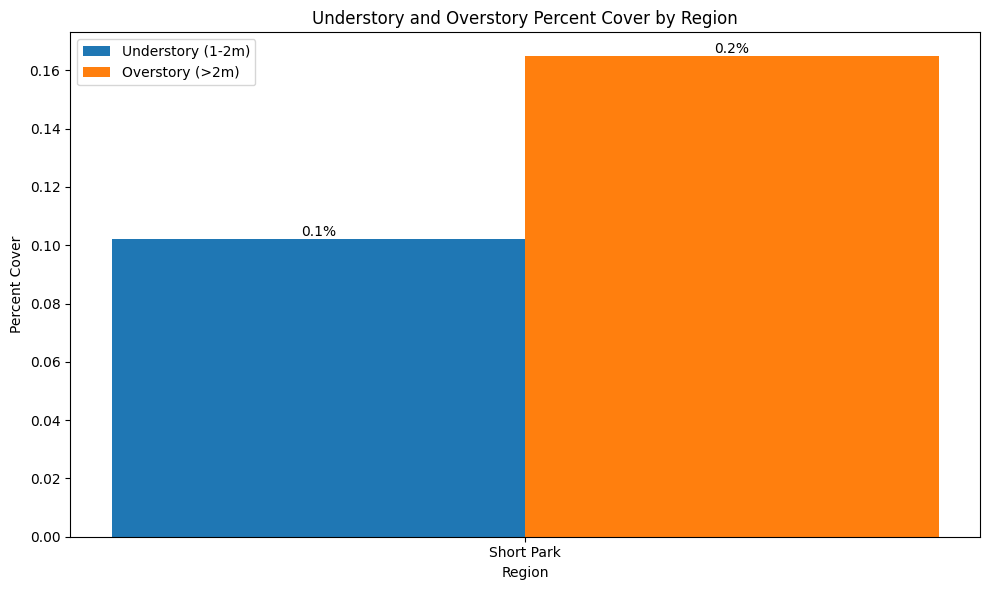

In [39]:

fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.35
index = np.arange(len(summary_stats))

# Create the bars
understory_bars = ax.bar(index, summary_stats['understory_percent'], bar_width, label='Understory (1-2m)')
overstory_bars = ax.bar(index + bar_width, summary_stats['overstory_percent'], bar_width, label='Overstory (>2m)')

# Add annotations
for bar in understory_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, height,  # Position text at center of the bar
        f"{height:.1f}%",  # Format the text
        ha='center', va='bottom', fontsize=10  # Alignment and font size
    )

for bar in overstory_bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2, height,
        f"{height:.1f}%",
        ha='center', va='bottom', fontsize=10
    )

# Set plot labels and title
ax.set_title('Understory and Overstory Percent Cover by Region')
ax.set_xlabel('Region')
ax.set_ylabel('Percent Cover')
ax.set_xticks(index + bar_width / 2)
ax.set_xticklabels(summary_stats['place'])
ax.legend()

plt.tight_layout()
plt.show()


In [40]:
overstory_markdown = f"""
## Overstory Statistics (Height > 2 meters)

**Total Canopy Area:** {canopy_area_sqft:.2f} square feet  

### **Canopy Height Statistics**
- **Mean Height:** {mean_height_ft:.2f} feet  
- **Median Height:** {median_height_ft:.2f} feet  
- **Minimum Height:** {min_height_ft:.2f} feet  
- **Maximum Height:** {max_height_ft:.2f} feet  
- **Standard Deviation of Height:** {std_dev_height_ft:.2f} feet  
"""

print(overstory_markdown)



## Overstory Statistics (Height > 2 meters)

**Total Canopy Area:** 2250.41 square feet  

### **Canopy Height Statistics**
- **Mean Height:** 13.91 feet  
- **Median Height:** 11.54 feet  
- **Minimum Height:** 6.56 feet  
- **Maximum Height:** 43.42 feet  
- **Standard Deviation of Height:** 7.14 feet  



In [41]:
# Generate Overstory Statistics Markdown Table
overstory_markdown = f"""
## Overstory Statistics (Height > 2 meters)

| Total Canopy Area (sqft) | Mean Height (ft) | Median Height (ft) | Min Height (ft) | Max Height (ft) | Std Dev Height (ft) |
|-------------------------|-----------------|-----------------|-----------------|-----------------|------------------|
| {canopy_area_sqft:.2f} | {mean_height_ft:.2f} | {median_height_ft:.2f} | {min_height_ft:.2f} | {max_height_ft:.2f} | {std_dev_height_ft:.2f} |
"""

print(overstory_markdown)



## Overstory Statistics (Height > 2 meters)

| Total Canopy Area (sqft) | Mean Height (ft) | Median Height (ft) | Min Height (ft) | Max Height (ft) | Std Dev Height (ft) |
|-------------------------|-----------------|-----------------|-----------------|-----------------|------------------|
| 2250.41 | 13.91 | 11.54 | 6.56 | 43.42 | 7.14 |



In [42]:
gdf

,place,area,geometry,canopy_min,canopy_max,canopy_mean,canopy_std,canopy_median,canopy_area,understory_area,understory_percent,overstory_area,overstory_percent,canopy_cover_percent
0,Short Park,78286.309453,"MULTIPOLYGON Z (((714532.864 3581758.736 0, 71...",0.032874,43.418806,0.099492,0.844249,0.033591,27149.300099,80.01,0.102167,129.06,0.1648,0.267058


In [43]:
# Generate Study Area Statistics Markdown
study_area_markdown = f"""
## Study Area Canopy Statistics

| Total Area (sqft) | Canopy Min Height (ft) | Canopy Max Height (ft) | Mean Height (ft) | Std Dev Height (ft) | Total Canopy Area (sqft) |
|------------------|----------------------|----------------------|----------------|-----------------|----------------------|
| {gdf['area'].sum():,.0f} | {gdf['canopy_min'].min():.2f} | {gdf['canopy_max'].max():.2f} | {gdf['canopy_mean'].mean():.2f} | {gdf['canopy_std'].mean():.2f} | {gdf['canopy_area'].sum():,.0f} |
"""

print(study_area_markdown)



## Study Area Canopy Statistics

| Total Area (sqft) | Canopy Min Height (ft) | Canopy Max Height (ft) | Mean Height (ft) | Std Dev Height (ft) | Total Canopy Area (sqft) |
|------------------|----------------------|----------------------|----------------|-----------------|----------------------|
| 78,286 | 0.03 | 43.42 | 0.10 | 0.84 | 27,149 |



In [44]:
overstory_understory_markdown = "## Overstory & Understory Statistics by Region\n\n"
overstory_understory_markdown += "| Region | Canopy Cover (%) | Understory Area (sqft) | Overstory Area (sqft) | Understory (%) | Overstory (%) |\n"
overstory_understory_markdown += "|--------|-----------------|------------------------|-----------------------|---------------|--------------|\n"

for _, row in gdf.iterrows():
    overstory_understory_markdown += f"| {row['place']} | {row['canopy_cover_percent']:.2f} | {row['understory_area']:.2f} | {row['overstory_area']:.2f} | {row['understory_percent']:.2f} | {row['overstory_percent']:.2f} |\n"

print(overstory_understory_markdown)


## Overstory & Understory Statistics by Region

| Region | Canopy Cover (%) | Understory Area (sqft) | Overstory Area (sqft) | Understory (%) | Overstory (%) |
|--------|-----------------|------------------------|-----------------------|---------------|--------------|
| Short Park | 0.27 | 80.01 | 129.06 | 0.10 | 0.16 |



In [45]:
#gdf.to_file(nm_path, layer='lordsburg_tc_ft', driver='GPKG')